**<h1>Nuclear Pulse Generator in SoM Kria™ KR260</h1>**

This notebook configures and operates an FPGA-based synthetic pulse generator implemented on the **Kria KR260** platform using the **PYNQ** framework. The objective is to generate realistic detector-like analog signals with programmable energy distributions and pulse shapes, enabling the emulation of radiation detection events for testing and validation of digital signal processing pipelines.

The implemented system uses a custom FPGA overlay (`pileup_v1.bit`) capable of generating individual pulses or multiple overlapping pulses (**pileup**) to reproduce high-count-rate detector conditions. The pulse amplitudes are sampled according to a predefined energy spectrum—in this case, a simulated **Cs-137**, **Co-60**, or **Eu-152** spectrums—while the pulse shape is modeled using a bi-exponential function that approximates the temporal response of common radiation detectors.

This setup allows the FPGA to generate synthetic detector signals with realistic statistical and temporal characteristics, which can be routed to an external DAC and adquired for DAQ (Digital Adquisition System) for further digital processing, such as FIR filtering and signal reconstruction. The platform provides a controlled environment for validating acquisition chains, studying pulse pileup effects, and comparing measured signals against theoretical detector models.

In [368]:
# Reset the PL fabric to a clean state before loading a new bitstream
from pynq import PL
PL.reset()

In [369]:
#Libraries Import
from pynq import Overlay, MMIO
import numpy as np
import matplotlib.pyplot as plt

Two platform configurations are available for synthetic pulse generation:

- **`not_pileup.bit`**: Platform implementing pulse generation logic for producing isolated detector pulses, without pulse overlap (*no pileup*). This configuration is intended for baseline signal validation and individual pulse analysis.

- **`pileup_v1.bit`**: Enhanced platform implementing pulse generation logic with integrated support for **pulse pileup and stacking**, allowing the superposition of up to **three overlapping pulses**. This configuration enables the emulation of high event-rate detector conditions, where pulse coincidence and distortion effects become relevant.

In [ ]:
# Load FPGA overlay
ol = Overlay("./platforms/pileup_v1.bit")

# Display accessible FPGA resources
print("Accessible IP Cores:")
for ip in ol.ip_dict.keys():
    print(f"  - {ip}")

print("\nAccessible Memories:")
for mem in ol.mem_dict.keys():
    print(f"  - {mem}")

Accessible IP Cores:
  - gpio_control/axi_gpio_0
  - gpio_control/axi_gpio_1
  - gpio_control/axi_gpio_2
  - gpio_control/axi_gpio_3
  - zynq_ultra_ps_e_0

Accessible Memories:
  - axi_bram_ctrl_0
  - axi_bram_ctrl_1
  - PSDDR


**<h2>BRAM and GPIO Initialization</h2>**

The BRAM controllers used for synthetic pulse generation are accessed through the overlay memory dictionary. Two memory regions are initialized:

- **`axi_bram_ctrl_0` (`BRAM_SIG`)**: Stores the pulse waveform template used as the detector signal shape.
- **`axi_bram_ctrl_1` (`BRAM_CDF`)**: Stores a frequency-expanded lookup table derived from the detector energy spectrum. Each channel value is repeated according to its relative occurrence probability, allowing the FPGA to randomly select pulse amplitudes with the same statistical distribution as the original spectrum.

The physical base addresses and memory ranges are retrieved and mapped using `MMIO`, enabling direct read/write access from Python.

Additionally, the GPIO interfaces are assigned for FPGA control and monitoring:

- **AXI GPIO 0** → Event enable **(`0x0`, write)** and output source selection **(`0x8`, write)**
- **AXI GPIO 1** → Probability threshold **(`0x0`, write)** and target number of events **(`0x8`, write)**  
- **AXI GPIO 2** → DC offset configuration **(`0x0`, write)** and completion status **(`DONE`, `0x8`, read)**  
- **AXI GPIO 3** → Frequency table length configuration **(`0x0`, write)** and signal BRAM update flag, used to notify the programmable logic (PL) that a new predefined pulse has been written **(`0x8`, write)**

In [371]:
BRAM_SIG_info = ol.mem_dict['axi_bram_ctrl_0']
BRAM_CDF_info = ol.mem_dict['axi_bram_ctrl_1']

print("BRAM_SIG")
print("   Controller addr:", hex(BRAM_SIG_info['phys_addr']))
print("   address range:", BRAM_SIG_info['addr_range'])
print("   BRAM Depth:", BRAM_SIG_info['addr_range']//4) 
print("BRAM_CDF")
print("   Controller addr:", hex(BRAM_CDF_info['phys_addr']))
print("   address range:", BRAM_CDF_info['addr_range'])
print("   BRAM Depth:", BRAM_CDF_info['addr_range']//4)


sig_bram_base_addr = BRAM_SIG_info['phys_addr']
sig_bram_range_addr = BRAM_SIG_info['addr_range']

cdf_bram_base_addr = BRAM_CDF_info['phys_addr']
cdf_bram_range_addr = BRAM_CDF_info['addr_range']

sig_bram = MMIO(sig_bram_base_addr, sig_bram_range_addr)
cdf_bram = MMIO(cdf_bram_base_addr, cdf_bram_range_addr)

#GPIO 0: ENABLE_EVENTS (wr) & SELECTOR (wr)
#GPIO 1: PROBABILITY THRESHOLD (wr) & TARGET_EVENTS (wr)
#GPIO 2: DC OFFSET (wr) & DONE (rd)
#GPIO 3: #CHA_FREQS_LENGHT (wr)
gpio_0 = ol.gpio_control.axi_gpio_0
gpio_1 = ol.gpio_control.axi_gpio_1
gpio_2 = ol.gpio_control.axi_gpio_2
gpio_3 = ol.gpio_control.axi_gpio_3

BRAM_SIG
   Controller addr: 0x80000000
   address range: 8192
   BRAM Depth: 2048
BRAM_CDF
   Controller addr: 0x82000000
   address range: 32768
   BRAM Depth: 8192


**<h2>Spectrum Loading and Probability Table Generation</h2>**

A simulated detector energy spectrum (`./specs/cs137_sim.txt`) is loaded and limited to **1024 channels**, matching the desired spectral resolution of the pulse generator. The spectrum is plotted to verify the expected distribution before processing.

To enable efficient hardware-based random amplitude selection, the spectrum is converted into a **frequency-expanded lookup table** (`CH_FREQS`). The normalized channel probabilities are scaled to a fixed table size defined as a power of two:

- **Number of channels:** `1024`
- **Target lookup table length:** `2^12 = 4096`

Each channel index is repeated according to its relative occurrence probability, producing a memory structure that preserves the statistical shape of the original spectrum while allowing simple uniform random addressing inside the FPGA.

A correction step compensates rounding errors to ensure that the final lookup table length matches the exact target size.

The resulting sampled distribution is then reconstructed and plotted to confirm that the generated lookup table accurately reproduces the original spectral probability density.

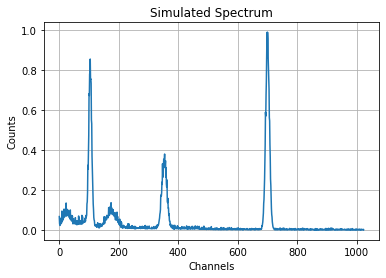

In [372]:
# Load the simulated Cs-137 energy spectrum, truncate it to match
# the 1024-channel system resolution, and visualize the spectrum
# before converting it into the frequency lookup table.

CHANNELS = 1024

spec = np.loadtxt("./specs/cs137_sim.txt")
spec = spec[0:CHANNELS]

plt.plot(spec)
plt.title("Simulated Spectrum")
plt.xlabel("Channels")
plt.ylabel("Counts")
plt.grid()
plt.show()

TARGET_LENGTH : 4096
REAL_LENGTH   : 4096
Power of 2    : True


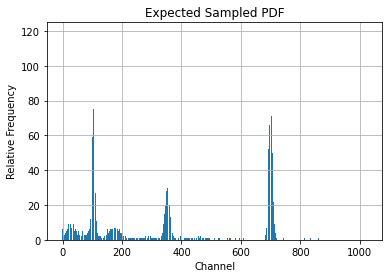

In [373]:
# Define lookup table size as a power of two for efficient FPGA addressing
ADDR_WIDTH = 12
TARGET_LENGTH = 2**ADDR_WIDTH

# Normalize the spectrum to obtain channel probabilities
freqs = spec / np.sum(spec)

# Scale probabilities to the desired lookup table length
freqs_int = np.round(freqs * TARGET_LENGTH).astype(np.uint32)

# Correct rounding error to guarantee exact table size
diff = TARGET_LENGTH - np.sum(freqs_int)
if diff != 0:
    # Compensate by adjusting the most probable channel
    idx = np.argmax(freqs_int)
    freqs_int[idx] += diff

# Generate frequency-expanded channel lookup table
# Each channel index is repeated according to its relative probability
CH_FREQS = np.repeat(np.arange(CHANNELS), freqs_int)

# Verify generated table properties
print("TARGET_LENGTH :", TARGET_LENGTH)
print("REAL_LENGTH   :", len(CH_FREQS))
print("Power of 2    :", (len(CH_FREQS) & (len(CH_FREQS) - 1)) == 0)

# Reconstruct sampled distribution for validation
counts = np.bincount(CH_FREQS, minlength=CHANNELS)
pdf_rec = counts

# Plot reconstructed probability distribution
plt.bar(range(CHANNELS), pdf_rec)
plt.title("Expected Sampled PDF")
plt.xlabel("Channel")
plt.ylabel("Relative Frequency")
plt.grid()
plt.show()

**<h3>DAC Resolution Normalization</h3>**

After generating the frequency table, all channel values are linearly scaled to match the **14-bit DAC resolution** used by the output hardware:

- **DAC range:** `0 → 16383` (`2^14 - 1`)

This normalization ensures that the selected spectral amplitudes can be directly used as pulse-height values during synthetic signal generation.

In [374]:
#Normalize to 2**14 DAC_RESOLUTION (MAX CHANNEL IS 16383)
CH_FREQS = (CH_FREQS * (2**14 - 1) / CH_FREQS.max()).astype(np.uint32)

In [375]:
# Configure the CH_FREQS table length, check BRAM capacity,
gpio_3.write(0x0, len(CH_FREQS))

if len(CH_FREQS) > BRAM_CDF_info['addr_range'] // 4:
    print("WARNING: BRAM depth is insufficient for the current CH_FREQS size.")
    print("Please reduce the data bit depth or increase the BRAM depth in hardware.")
    print("Size:", len(CH_FREQS))
 
else:
    # write the frequency lookup table into BRAM_CDF, and verify
    cdf_bram.array[0:len(CH_FREQS)] = CH_FREQS
    
    # successful programming through a readback test.
    test_addr = 200
    print("BRAM Write test:")
    print("BRAM lecture:", cdf_bram.read(test_addr*4))
    print("Expected:", CH_FREQS[test_addr])

BRAM Write test:
BRAM lecture: 548
Expected: 548


**<h2>Synthetic Pulse Generation and BRAM Signal Writing</h2>**

A synthetic detector pulse waveform is generated using a **bi-exponential model**, which approximates the temporal response of radiation detection systems through a fast rise and a slower decay component.

The pulse is discretized into **512 samples** using the DAC sampling clock (**50 MHz**, corresponding to a **20 ns** sampling period), producing a digital waveform suitable for direct hardware playback.

The generated signal is then:

- **Normalized** to its maximum amplitude
- **Scaled** to the full **14-bit DAC dynamic range** (`0–16383`)
- **Visualized** to verify the expected pulse shape

Once validated, the waveform is transferred to **`BRAM_SIG`**, which stores the predefined detector pulse template used by the FPGA pulse generator.

Before writing the new signal, the BRAM contents are cleared to avoid residual data. After programming, a **BRAM update flag** is toggled through **AXI GPIO 3** to notify the programmable logic (PL) that a new waveform is available.

Finally, a memory **readback verification** is performed by comparing a selected BRAM value against the expected waveform sample, ensuring correct signal storage and synchronization between the processing system (PS) and FPGA hardware.

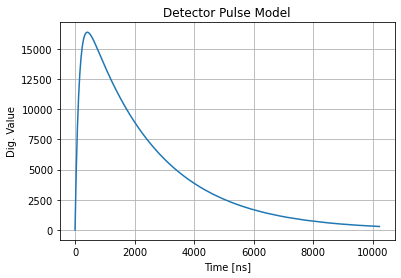

DAC Sampling Period: 20.0 [ns]


In [377]:
samples = 512               #Total Samples of pulse
DAC_CLK = 50e6              #Clock Frequency of DAC sampling
DAC_PERIOD = 1/DAC_CLK*1e9  #Time in ns

# Define the synthetic detector pulse shape using a bi-exponential

def biexp(t, A, tau_f, tau_s):
    y = A * (np.exp(-t / tau_f) - np.exp(-t / tau_s))
    return -y

# Generate time axis for pulse definition
t = np.linspace(0, 30e-6, samples)

# Pulse model parameters
A = 1.0
tau_f = 0.4e-6   # Fast rise constant
tau_s = 7e-6     # Slow decay constant

# Compute pulse waveform
y = biexp(t, A, tau_f, tau_s)

# Normalize and scale to 14-bit DAC range
scale = 2**14 - 1
y = y / y.max()
y = np.uint32(y * scale)

# Plot resulting digital pulse
plt.plot(np.arange(len(y)) * DAC_PERIOD, y)
plt.title("Detector Pulse Model")
plt.xlabel("Time [ns]")
plt.ylabel("Dig. Value")
#plt.savefig("signal.png")
plt.grid()
plt.show()

print("DAC Sampling Period:", DAC_PERIOD, "[ns]")

In [378]:
# Clear the entire signal BRAM to remove any previous waveform data
sig_bram.array[0:sig_bram_range_addr//4] = np.zeros(sig_bram_range_addr//4)

# Write the generated detector pulse model into BRAM_SIG
sig_bram.array[0:samples] = y

# Toggle the BRAM update flag to notify the programmable logic (PL)
# that a new predefined signal waveform is available
gpio_3.write(0x8, 1)
gpio_3.write(0x8, 0)

# Read back a sample memory location and compare it with the
# expected waveform value to verify correct BRAM programming
sig_test_addr = 121
print("BRAM Write test:")
print("BRAM lecture:", sig_bram.read(sig_test_addr*4))
print("Expected:", y[sig_test_addr])

BRAM Write test:
BRAM lecture: 7491
Expected: 7491


**<h3>DAC Output Source Selection</h3>**

The FPGA output source is selected through **AXI GPIO 0**, allowing different internal signals to be routed to the DAC for testing and validation purposes. Available output modes include:

- **0** → ADC input after clock-domain crossing (CDC) *(not available)*
- **1** → ADC input before CDC *(not available)*

- **2** → Digital ramp test signal  
- **3** → Fixed DC offset value  
- **4** → Predefined pulse waveform stored in **`BRAM_SIG`**  

In [429]:

gpio_0.write(0x8, 3)

#=================RESERVED FOR DC OFFSET VALUE==================================
def volt_dig(voltage, vref=1.0, bits=14):
    max_digital = (2**bits) - 1
    
    # Limitar el voltaje al rango válido
    if voltage < 0:
        voltage = 0
    elif voltage > vref:
        voltage = vref

    digital_value = int((voltage / vref) * max_digital)

    return digital_value

volt = 0.10

dc_val = volt_dig(volt, vref=1.0, bits=14)
gpio_2.write(0x0, dc_val)
#===============================================================================

**<h2>Set and Execute Event Generation</h2>**

The pulse generator is configured by defining the **total number of synthetic events** to be produced and the **event generation probability threshold**.

The probability threshold controls the likelihood of event creation at each FPGA clock cycle. Increasing this value raises the event rate and, when using the **`pileup_v1.bit`** platform, increases the probability of overlapping pulses (**pileup**), enabling the emulation of high-count-rate detector conditions.

The FPGA then autonomously generates detector events according to the predefined pulse waveform, spectral amplitude distribution, target event count, and probability threshold.

During execution, the software continuously polls the **DONE** status flag until the FPGA indicates that the requested number of events has been successfully generated.

After completion, event generation is disabled, and the total number of generated pulses is reported.

This process produces a fully synthesized detector-like output signal, ready to be transmitted through the DAC for external measurement or re-acquisition through an ADC-based digital processing chain.

In [392]:
# Configure the total number of synthetic pulse events
TARGET_EV = 10000
gpio_1.write(0x8, TARGET_EV)

# Set the event generation probability threshold.
# Higher values increase the event rate and the likelihood
# of pulse overlap (pileup) during signal generation.
PROB = 0.001
gpio_1.write(0x0, int(PROB * 2**32))

# Read the DONE status flag to check whether the pulse generation process has completed
print("Done:", gpio_2.read(0x8))

Done: 0


In [393]:
# Enable automatic synthetic event generation
gpio_0.write(0x0, 1)

# Wait until the FPGA asserts the DONE flag,
# indicating that the requested number of events
# has been successfully generated
while gpio_2.read(0x8) == 0:
    pass

# Disable event generation after completion
gpio_0.write(0x0, 0)

# Display total number of generated events
print("Total Events Generated:", TARGET_EV)

Total Events Generated: 10000


In [239]:
#Force disable Events Generation
gpio_0.write(0x0, 0)

________________

<h2>Additional Information</h2>

**<h3>DAC Transfer Function Characterization</h3>**

This cell evaluates the analog response of the DAC with respect to the programmed voltage values (`v_set`).

A set of voltage points from 0 V to 1 V is applied, and the corresponding DAC output voltage (`v_dac`) is measured experimentally.

The DAC transfer function is modeled as:

$$V_{dac} = m \cdot V_{set} + b$$

where:

- $m : -1862.06 \ [mV]$ (Slope)

- $b : 953.31 \ [mV]$ (Offset Level)

Slope: -1862.0664935064924
Offset: 953.3103896103894


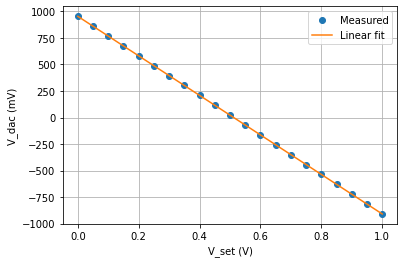

In [441]:
# Measured DAC output voltage values (mV) obtained for each programmed input voltage
v_dac = [
    952.86, 859.43, 766.26, 674.06, 581.46,
    487.80, 395.13, 301.93, 208.33, 115.73,
    22.66, -70.13, -163.20, -256.73, -350.06,
    -443.06, -536.46, -630.00, -722.93, -815.93,
    -909.33
]

# Programmed DAC voltage sweep from 0 V to 1 V with 0.05 V step
v_set = np.arange(0, 1.05, 0.05)

# Linear fit of the DAC transfer function: V_dac = m·V_set + b
# m: gain (slope), b: offset (intercept)
m, b = np.polyfit(v_set, v_dac, 1)

# Display fitted calibration parameters
print("Slope:", m)
print("Offset:", b)

# Plot measured DAC response points
plt.plot(v_set, v_dac, 'o', label='Measured')

# Plot linear regression model
plt.plot(v_set, m * v_set + b, label='Linear fit')

# Axis labels
plt.xlabel("V_set (V)")
plt.ylabel("V_dac (mV)")

# Add grid and legend for clarity
plt.grid()
plt.legend()

# Display transfer function plot
plt.show()

In [443]:
import pynq
print(pynq.__version__)

3.0.1
